
# Stream Macroinvertebrates Image Classification Using MobileNet, EfficientNet  and Vision Transformer Models
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with **MobileNet**,  **EfficientNet** and **Vision Transformer Model** pretrained on ImageNet
### 5. Train, evaluate, and predict on new images


In [ ]:
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle (https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/data ) and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



In [3]:
#!unzip archive.zip

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Mobile-Net Model**

In [5]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/insects_dataset/train_data/'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




Loading dataset with 80/20 train-validation split...
Found 1380 files belonging to 3 classes.
Using 1104 files for training.
Found 1380 files belonging to 3 classes.
Using 276 files for validation.
Classes found: ['Gammarus sp', 'Leuctra sp', 'Simuliidae sp']


In [6]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

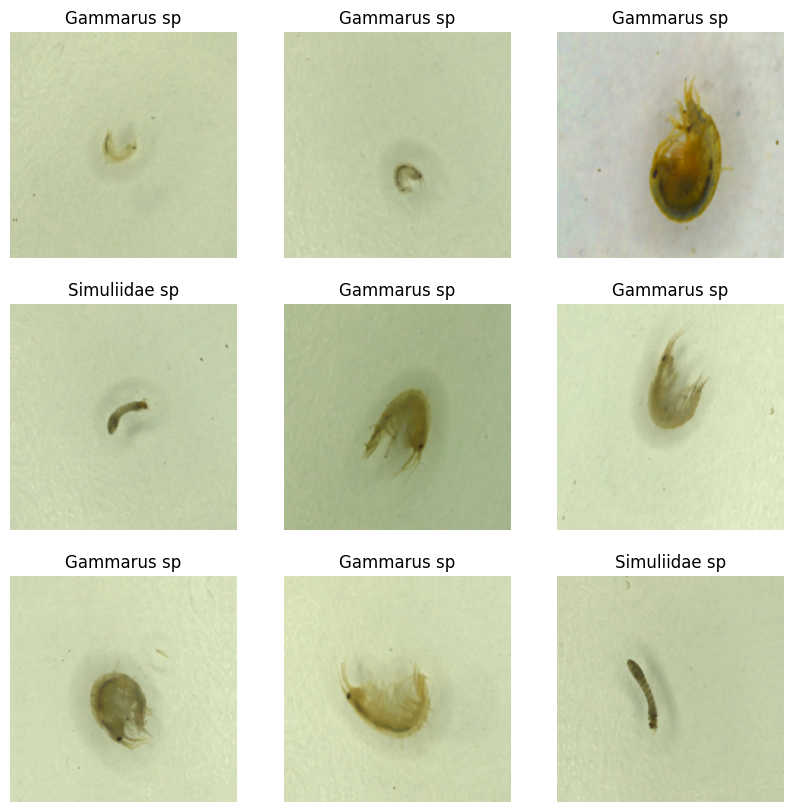

In [7]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.8723 - loss: 0.3386 - val_accuracy: 0.9819 - val_loss: 0.0963
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - accuracy: 0.9728 - loss: 0.0947 - val_accuracy: 0.9928 - val_loss: 0.0338
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.9837 - loss: 0.0530 - val_accuracy: 0.9964 - val_loss: 0.0186
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.9928 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0133
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 400ms/step - accuracy: 0.9946 - loss: 0.0275 - val_accuracy: 1.0000 - val_loss: 0.0099
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.9946 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 388ms/step - accuracy: 0.9946 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 397ms/step - accuracy: 0.9982 - loss: 0.0153 - val_accura

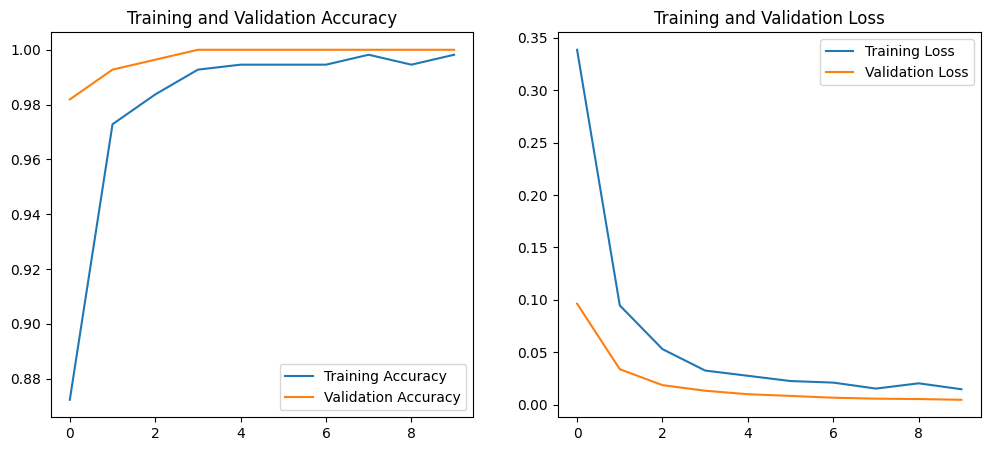

In [10]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [11]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 1.0000 - loss: 0.0046
Validation accuracy: 100.00%


In [12]:
# === STEP 9: Save the trained model ===
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
Model saved as 'macroinvertebrates_classifier.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

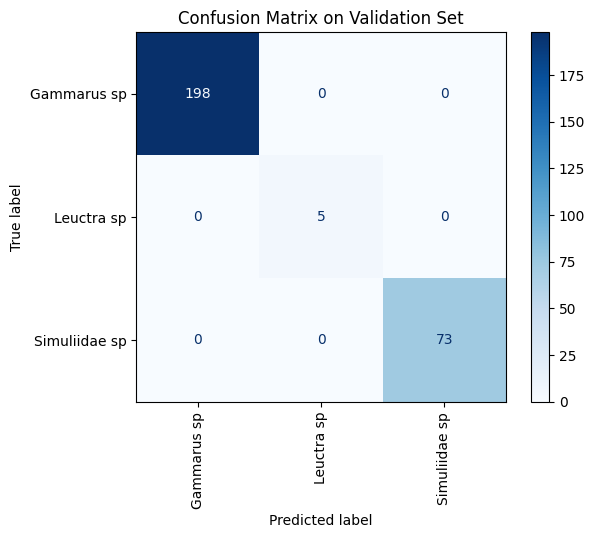

Weighted Precision: 1.0000
Weighted Recall:    1.0000
Weighted F1-score:  1.0000


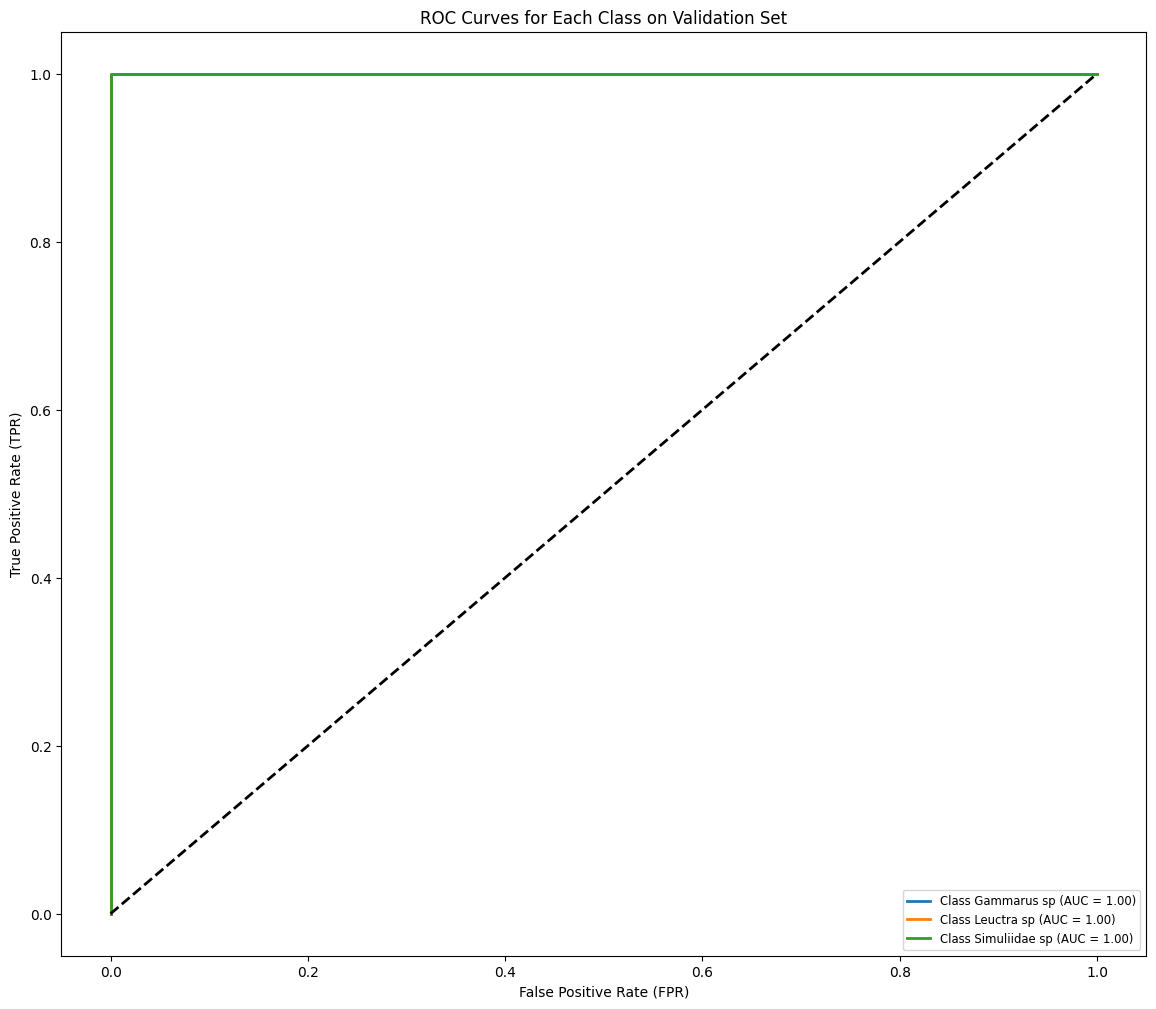

In [13]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [14]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.


**2. EfficientNet Model**

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os


In [53]:
DATASET_DIR = '/content/drive/MyDrive/insects_dataset/train_data/'

In [17]:
IMG_SIZE = (224, 224)        # EfficientNetB0 default input size
BATCH_SIZE = 32
SEED = 123

In [54]:
# === STEP 1: Load dataset with 80/20 train-validation split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 1380 files belonging to 3 classes.
Using 1104 files for training.
Found 1380 files belonging to 3 classes.
Using 276 files for validation.
Classes: ['Gammarus sp', 'Leuctra sp', 'Simuliidae sp']


In [20]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

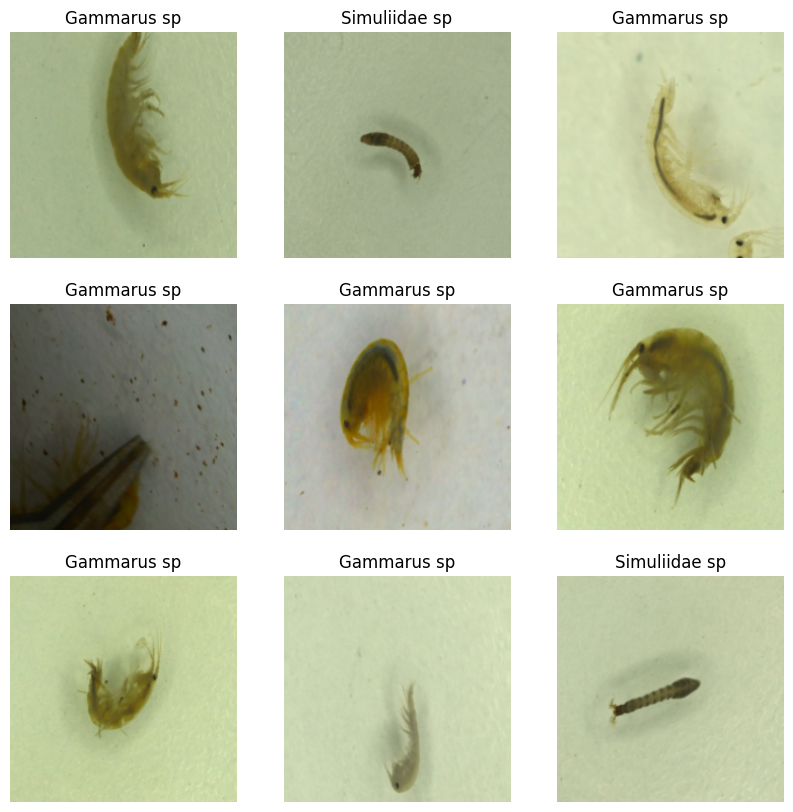

In [21]:
# === STEP 3: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Optional: visualize augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [22]:
# === STEP 4: Build transfer learning model with EfficientNetB0 ===

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)               # apply augmentation
x = tf.keras.applications.efficientnet.preprocess_input(x)  # preprocess as EfficientNet expects
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 491ms/step - accuracy: 0.8478 - loss: 0.3911 - val_accuracy: 0.9674 - val_loss: 0.1356
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 413ms/step - accuracy: 0.9683 - loss: 0.1375 - val_accuracy: 0.9855 - val_loss: 0.0727
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 412ms/step - accuracy: 0.9774 - loss: 0.0959 - val_accuracy: 0.9928 - val_loss: 0.0490
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - accuracy: 0.9900 - loss: 0.0692 - val_accuracy: 0.9928 - val_loss: 0.0386
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - accuracy: 0.9900 - loss: 0.0579 - val_accuracy: 0.9964 - val_loss: 0.0308
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 426ms/step - accuracy: 0.9937 - loss: 0.0483 - val_accuracy: 0.9964 - val_loss: 0.0262
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 387ms/step - accuracy: 0.9937 - loss: 0.0424 - val_accuracy: 0.9964 - val_loss: 0.0232
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 426ms/step - accuracy: 0.9964 - loss: 0.0367 - val_accu

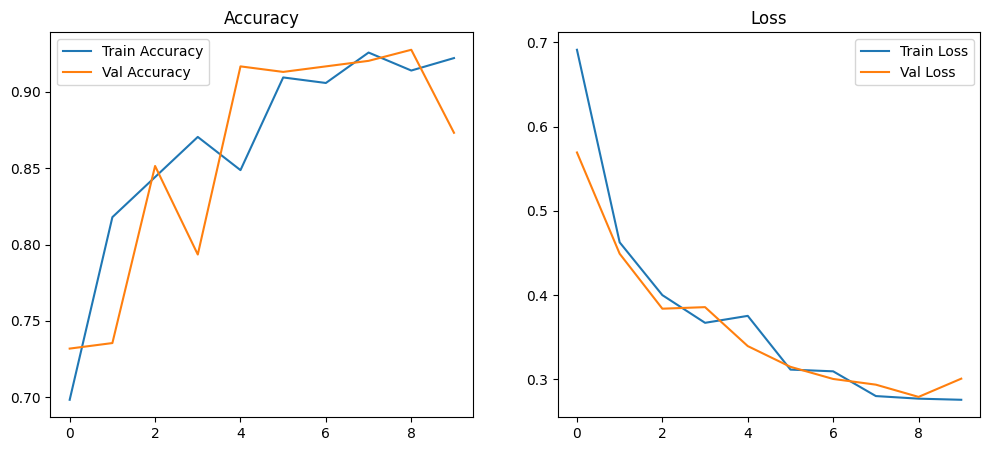

In [55]:
# === STEP 6: Plot training curves ===

acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 510ms/step - accuracy: 0.8931 - loss: 0.2818 - val_accuracy: 0.9275 - val_loss: 0.2772
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 499ms/step - accuracy: 0.9275 - loss: 0.2600 - val_accuracy: 0.9239 - val_loss: 0.2760
Epoch 12/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 510ms/step - accuracy: 0.9230 - loss: 0.2631 - val_accuracy: 0.9239 - val_loss: 0.2750
Epoch 13/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 466ms/step - accuracy: 0.9239 - loss: 0.2594 - val_accuracy: 0.9239 - val_loss: 0.2739
Epoch 14/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 470ms/step - accuracy: 0.9303 - loss: 0.2648 - val_accuracy: 0.9239 - val_loss: 0.2725
Epoch 15/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 481ms/step - accuracy: 0.9293 - loss: 0.2547 - val_accuracy: 0.9275 - val_loss: 0.2712
Epoch 16/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 496ms/step - accuracy: 0.9321 - loss: 0.2616 - val_accuracy: 0.9239 - val_loss: 0.2718
Epoch 17/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 469ms/step - accuracy: 0.9321 - loss: 0.2552 - 

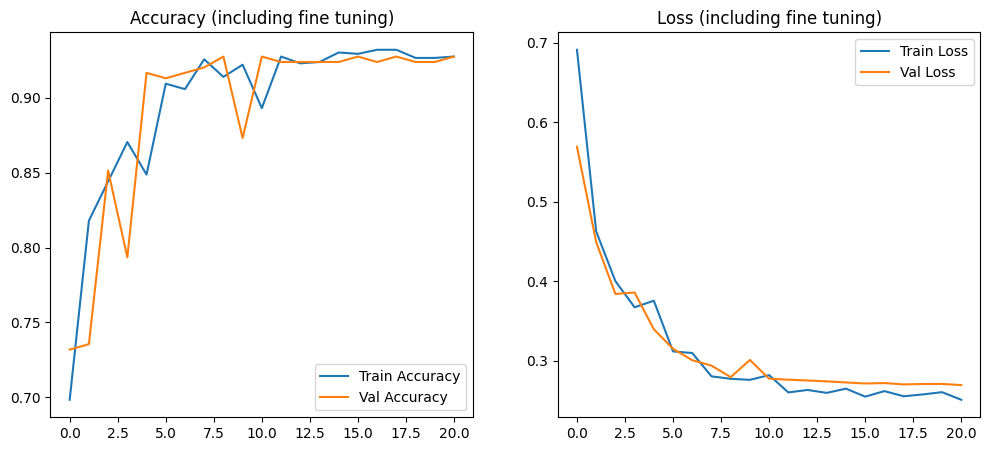

In [56]:
# === STEP 7 (Optional): Fine-tune base model ===

base_model.trainable = True

# Freeze initial layers, train last layers of EfficientNet
fine_tune_at = 100  # Freeze all layers before this
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

# Plot fine-tuning results (optional)
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy (including fine tuning)')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss (including fine tuning)')

plt.show()

In [60]:
# === STEP 8: Prediction on new images ===

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence

# Example usage:
test_img_path = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data/CPH-Asellus sp.-92-t.png'  # replace with your test image path
predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence * 100:.2f}%)')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data/CPH-Asellus sp.-92-t.png'

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<Figure size 1200x1200 with 0 Axes>

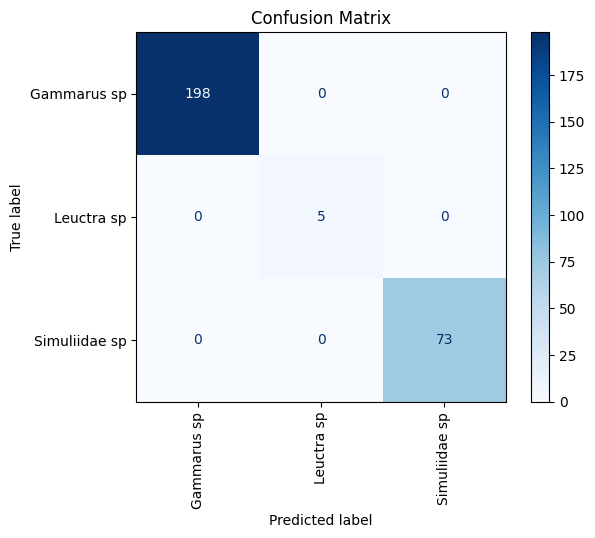

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


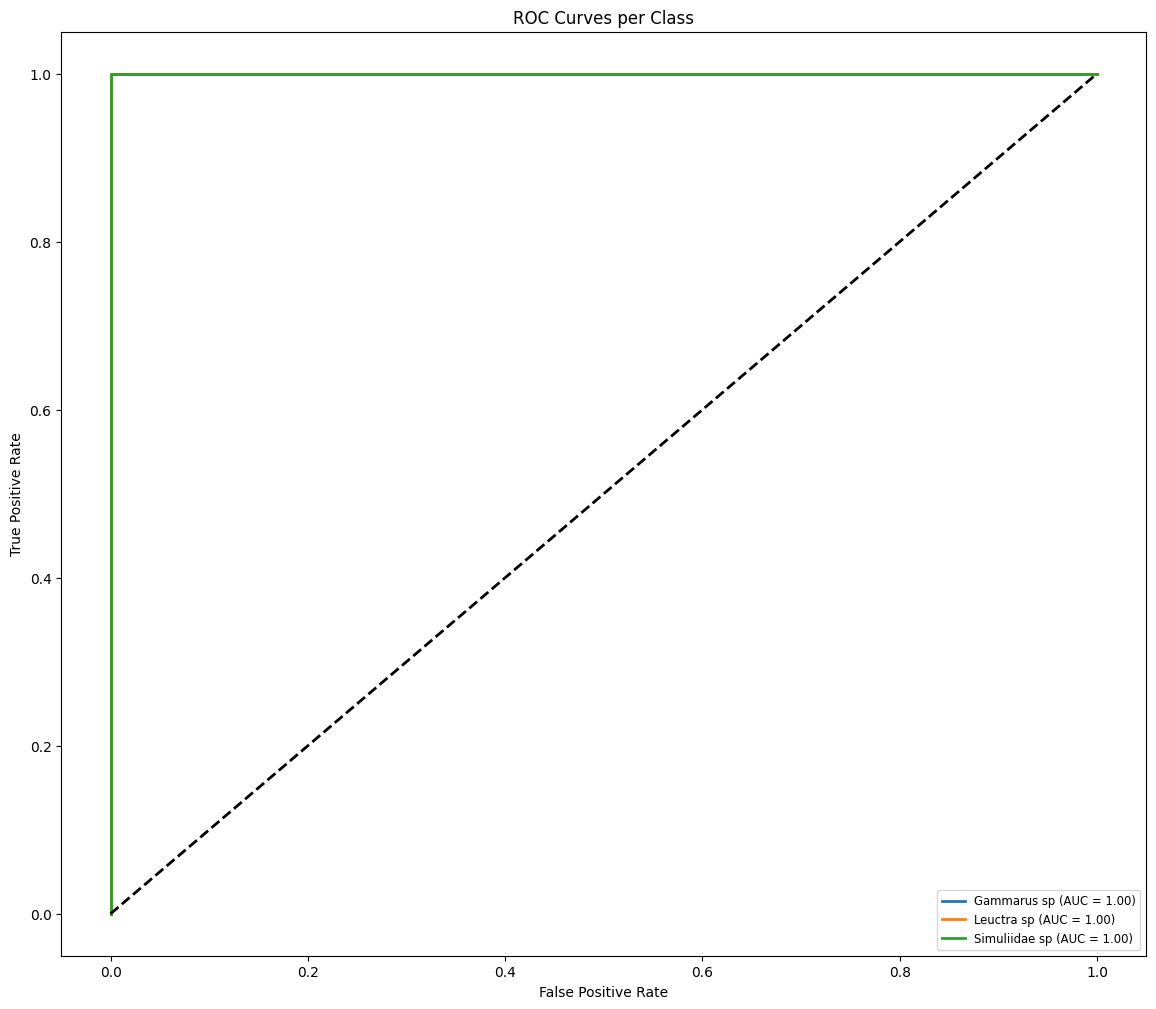

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Aggregate true labels and predictions from validation dataset
y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'  # options: 'micro', 'macro', None...
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC Curve and AUC for multi-class
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()


In [29]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.


**3. Vision Transformer Model**

In [30]:
#!pip install tensorflow tensorflow-hub tensorflow-datasets matplotlib


In [31]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

In [32]:
# === User parameters ===
DATASET_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/train_data/'  # Your insect dataset folder organized by classes
IMG_SIZE = 224            # ViT input size
BATCH_SIZE = 32
SEED = 123
EPOCHS = 10

In [33]:

# === Step 1: Load Dataset with 80/20 split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/train_data/'

In [34]:
# === Step 2: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [35]:
# === Step 3: Load ViT Feature Extractor from TF Hub ===

vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"
vit_layer = hub.KerasLayer(vit_url, trainable=False)

In [36]:
#====Step 4:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation
x = data_augmentation(inputs)

# The TF Hub ViT module expects pixel values in [0, 255].
# image_dataset_from_directory typically outputs float32 in [0, 255],
# and data_augmentation maintains this. So, no explicit [0,1] scaling is needed here.

# ViT feature extractor
# Wrap the vit_layer call in a Lambda layer to ensure proper symbolic tensor handling
features = tf.keras.layers.Lambda(lambda y: vit_layer(y))(x);

# Classification head
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(features)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:

# === Step 5: Train the model ===

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 40s 865ms/step - accuracy: 0.6984 - loss: 0.6913 - val_accuracy: 0.7319 - val_loss: 0.5694
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step - accuracy: 0.8179 - loss: 0.4627 - val_accuracy: 0.7355 - val_loss: 0.4492
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 517ms/step - accuracy: 0.8442 - loss: 0.4000 - val_accuracy: 0.8514 - val_loss: 0.3839
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 481ms/step - accuracy: 0.8705 - loss: 0.3672 - val_accuracy: 0.7935 - val_loss: 0.3858
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 483ms/step - accuracy: 0.8487 - loss: 0.3754 - val_accuracy: 0.9167 - val_loss: 0.3395
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 493ms/step - accuracy: 0.9094 - loss: 0.3116 - val_accuracy: 0.9130 - val_loss: 0.3149
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 698ms/step - accuracy: 0.9058 - loss: 0.3096 - val_accuracy: 0.9167 - val_loss: 0.3005
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 34s 497ms/step - accuracy: 0.9257 - loss: 0.2802 - val_accu

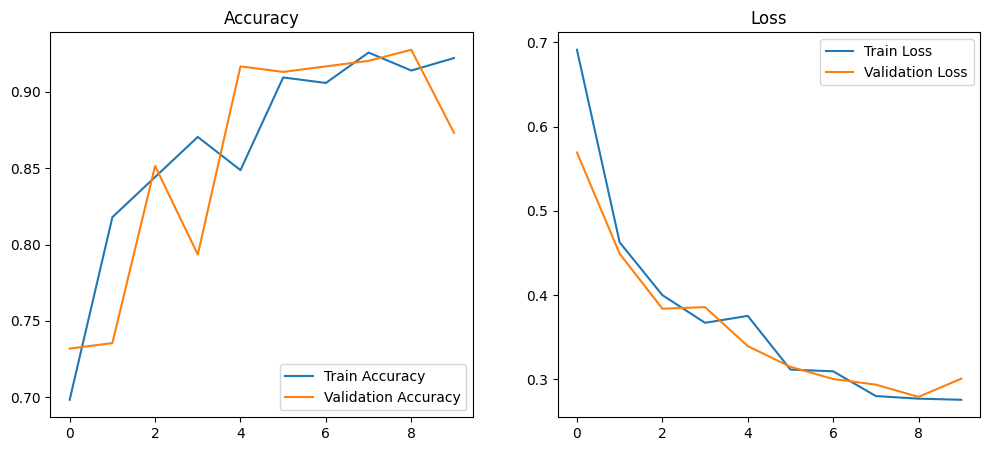

In [38]:
# === Step 6: Plot training & validation accuracy/loss ===

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [39]:
# === Step 7: Prediction helper function ===

def load_and_preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence


In [43]:
# === Example prediction ===
test_img_path = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data/CPH-Asellus sp.-93-v.png'  # Replace with your image path

predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(tf.keras.preprocessing.image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence*100:.2f}%)')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data/CPH-Asellus sp.-93-v.png'

In [42]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

# Ensure IMG_SIZE is treated as a tuple for this function
_target_img_size = (IMG_SIZE, IMG_SIZE) if not isinstance(IMG_SIZE, tuple) else IMG_SIZE

def load_and_preprocess_image(img_path, img_size=_target_img_size):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.


**Evaluation Report**
* Show performance comparison of three models (MobileNet, EfficientNet, VisionTransformer Models) in terms of their performance metrics


*  Confusion Matrix screenshots,
*  precision, recall, F1-measure table
* ROC curve screenshots.
